[KROK 1] Wczytywanie danych...
[KROK 2] Budowa modelu (Wejście: 38 -> Wyjście: 8)...
[KROK 3] Start treningu (40 epok)...
   Epoka 05 | Train Acc: 29.04% | Test Acc: 29.20%
   Epoka 10 | Train Acc: 29.90% | Test Acc: 29.91%
   Epoka 15 | Train Acc: 31.43% | Test Acc: 30.31%
   Epoka 20 | Train Acc: 31.78% | Test Acc: 31.37%
   Epoka 25 | Train Acc: 32.33% | Test Acc: 31.85%
   Epoka 30 | Train Acc: 32.88% | Test Acc: 31.71%
   Epoka 35 | Train Acc: 33.09% | Test Acc: 32.37%
   Epoka 40 | Train Acc: 32.99% | Test Acc: 32.87%


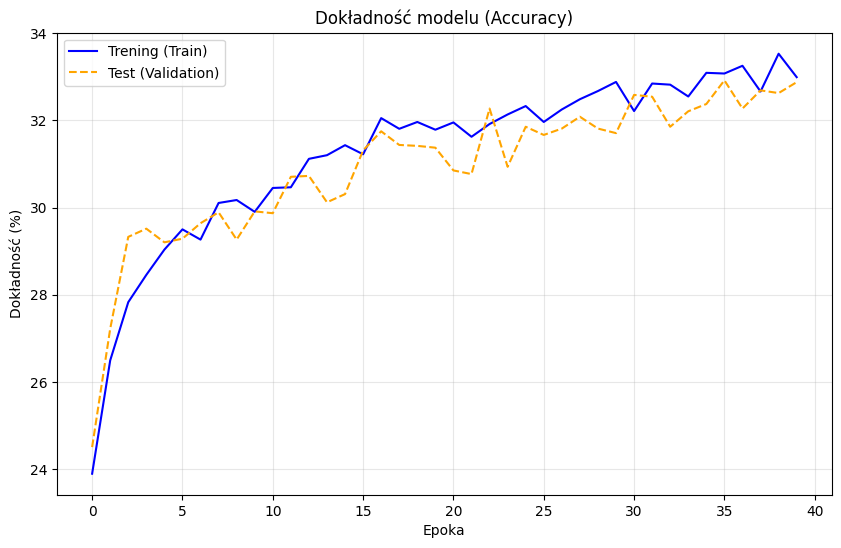


[KROK 4] Raport końcowy...
               precision    recall  f1-score   support

   Electronic       0.32      0.19      0.24       600
 Experimental       0.27      0.14      0.18       599
         Folk       0.32      0.30      0.31       600
      Hip-Hop       0.39      0.54      0.46       597
 Instrumental       0.35      0.53      0.42       599
International       0.24      0.28      0.26       600
          Pop       0.18      0.08      0.11       600
         Rock       0.38      0.57      0.46       599

     accuracy                           0.33      4794
    macro avg       0.31      0.33      0.31      4794
 weighted avg       0.31      0.33      0.30      4794

Generowanie macierzy pomyłek...


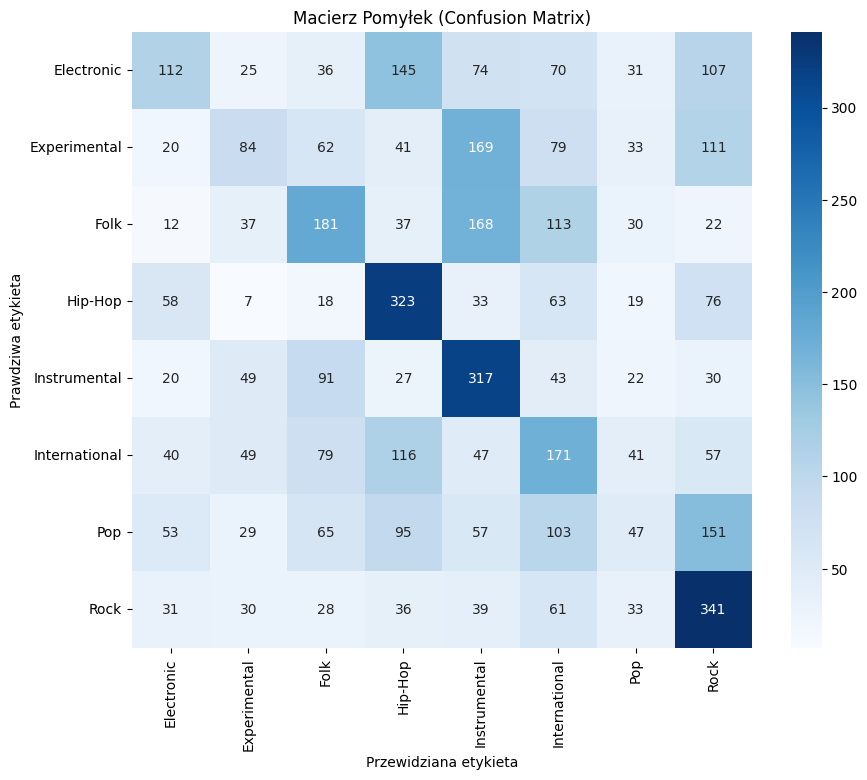

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# --- IMPORTY ---
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix 
import matplotlib.pyplot as plt
import seaborn as sns 

# ==============================================================================
# 1. KONFIGURACJA
# ==============================================================================
class Config:
    CSV_PATH = 'spectrogram_stats.csv'
    SEED = 42
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    EPOCHS = 40
    
    torch.manual_seed(SEED)
    np.random.seed(SEED)

# ==============================================================================
# 2. PRZYGOTOWANIE DANYCH
# ==============================================================================
def load_and_preprocess_data():
    print("[KROK 1] Wczytywanie danych...")
    
    if not os.path.exists(Config.CSV_PATH):
        raise FileNotFoundError(f"BŁĄD: Nie widzę pliku '{Config.CSV_PATH}'!")

    df = pd.read_csv(Config.CSV_PATH)
    
    cols_to_drop = ['track_id', 'min']
    actual_drop = [c for c in cols_to_drop if c in df.columns]
    
    X = df.drop(columns=['genre'] + actual_drop)
    y = df['genre']
    
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    num_classes = len(le.classes_)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y_encoded, test_size=0.2, random_state=Config.SEED, stratify=y_encoded
    )
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    return X_train, X_test, y_train, y_test, le, scaler, X_train.shape[1], num_classes

# ==============================================================================
# 3. DATASET I MODEL
# ==============================================================================
class AudioDataSet(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)
    def __len__(self): return len(self.features)
    def __getitem__(self, idx): return self.features[idx], self.labels[idx]

class GenreClassifier(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(GenreClassifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, output_dim)
        )
    def forward(self, x): return self.net(x)

# ==============================================================================
# 4. GŁÓWNY PROGRAM
# ==============================================================================

# A. Ładowanie
X_train, X_test, y_train, y_test, le, scaler, in_dim, out_dim = load_and_preprocess_data()

train_loader = DataLoader(AudioDataSet(X_train, y_train), batch_size=Config.BATCH_SIZE, shuffle=True)
test_loader = DataLoader(AudioDataSet(X_test, y_test), batch_size=Config.BATCH_SIZE, shuffle=False)

# B. Model
print(f"[KROK 2] Budowa modelu (Wejście: {in_dim} -> Wyjście: {out_dim})...")
model = GenreClassifier(in_dim, out_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)

# C. Trening
print(f"[KROK 3] Start treningu ({Config.EPOCHS} epok)...")

train_acc_history = []
test_acc_history = []

for epoch in range(Config.EPOCHS):
    # Faza Treningu
    model.train()
    correct_train = 0
    total_train = 0
    
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()
        
    epoch_train_acc = 100 * correct_train / total_train
    train_acc_history.append(epoch_train_acc)
    
    # Faza Testu
    model.eval()
    correct_test = 0
    total_test = 0
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            total_test += y_batch.size(0)
            correct_test += (predicted == y_batch).sum().item()
            
    epoch_test_acc = 100 * correct_test / total_test
    test_acc_history.append(epoch_test_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"   Epoka {epoch+1:02d} | Train Acc: {epoch_train_acc:.2f}% | Test Acc: {epoch_test_acc:.2f}%")

# D. Wykres Accuracy
plt.figure(figsize=(10, 6))
plt.plot(train_acc_history, label='Trening (Train)', color='blue')
plt.plot(test_acc_history, label='Test (Validation)', color='orange', linestyle='--')
plt.title("Dokładność modelu (Accuracy)")
plt.xlabel("Epoka")
plt.ylabel("Dokładność (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# E. Raport i Macierz Pomyłek
print("\n[KROK 4] Raport końcowy...")
model.eval()
all_preds = []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        out = model(X_batch)
        _, predicted = torch.max(out, 1)
        all_preds.extend(predicted.numpy())

# 1. Raport tekstowy
print(classification_report(y_test, all_preds, target_names=le.classes_))

# 2. Macierz Pomyłek
print("Generowanie macierzy pomyłek...")
cm = confusion_matrix(y_test, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Macierz Pomyłek (Confusion Matrix)')
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()